In [213]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, LeaveOneGroupOut, RandomizedSearchCV
from sklearn.linear_model import Ridge
from sklearn.multioutput import RegressorChain
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [214]:
from matplotlib.font_manager import FontProperties
from matplotlib.font_manager import findfont

#sns.set_palette([  "#89A8F6","#0F42C6",'#C9CED5',  "#1C2029"])

sns.set_style('darkgrid',{
    "axes.facecolor": "#f0f0f0",
    "axes.linewidth": 1.5,
    'axes.grid': True,
    'axes.labelcolor': '#000',
    "font.size": 18,
    'axes.edgecolor': '#fff',
    'grid.color': '#9d9d9d',
    'text.color': '#000',
    'xtick.color': '#000'
})

In [215]:
df = pd.read_csv("bench_results/results_B.csv")

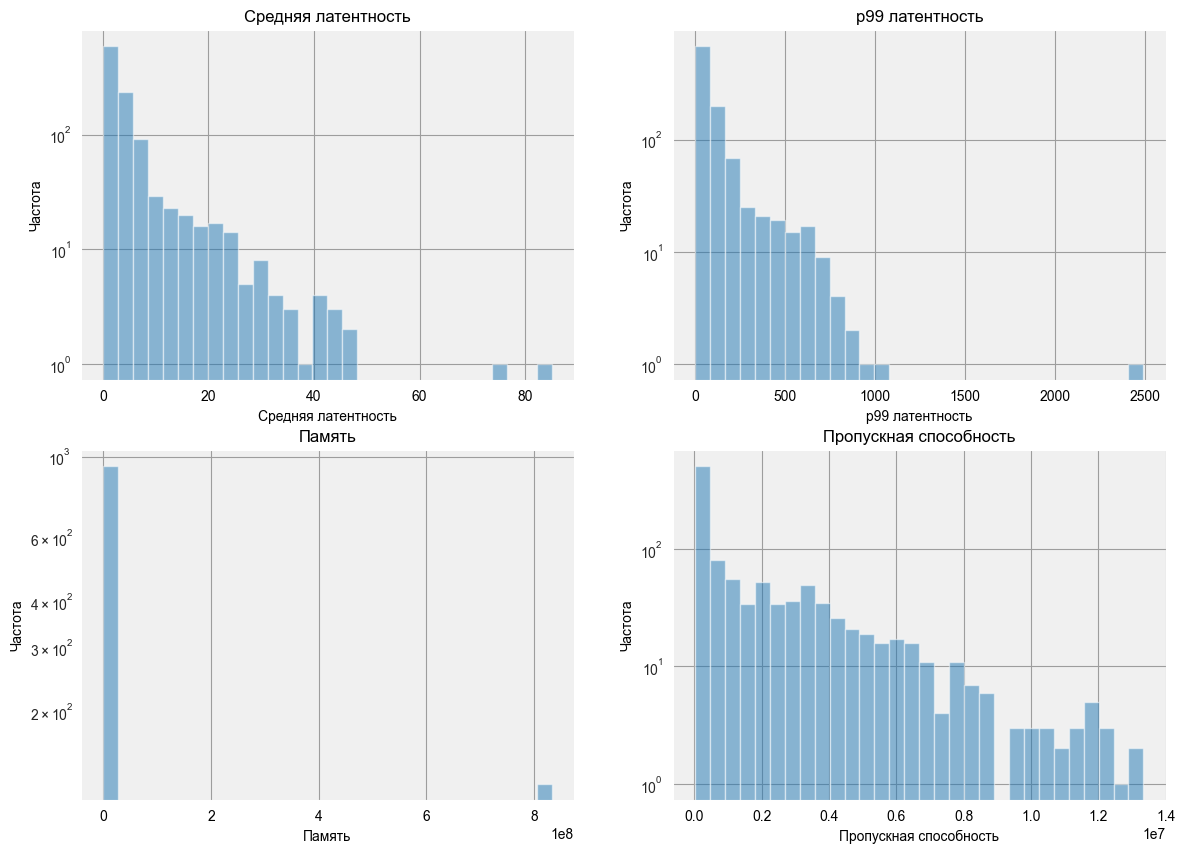

In [216]:
metrics = ['avg_latency_us', 'p99_latency_us', 'memory_usage_bytes', 'throughput_ops_sec']
titles = ['Средняя латентность', 'p99 латентность', 'Память', 'Пропускная способность']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric, title in zip(axes.flat, metrics, titles):
    ax.hist(df[metric], bins=30, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel('Частота')
    ax.set_yscale('log')

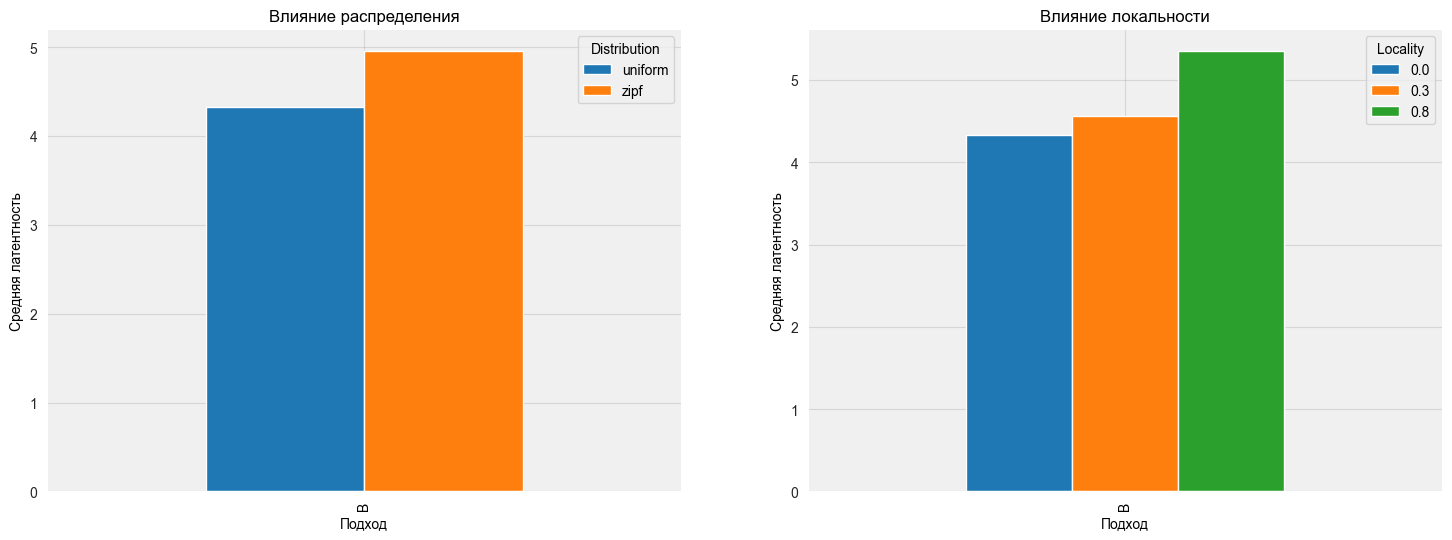

In [217]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

zipf_effect = df.groupby(['fs_type','distribution'])['avg_latency_us'].mean().unstack()
zipf_effect.plot(kind='bar', ax=axes[0])
axes[0].set_title('Влияние распределения')
axes[0].set_xlabel('Подход')
axes[0].set_ylabel('Средняя латентность')
axes[0].legend(title='Distribution')
axes[0].grid(True, alpha=0.3)

loc_effect = df.groupby(['fs_type','locality'])['avg_latency_us'].mean().unstack()
loc_effect.plot(kind='bar', ax=axes[1])
axes[1].set_title('Влияние локальности')
axes[1].set_xlabel('Подход')
axes[1].set_ylabel('Средняя латентность')
axes[1].legend(title='Locality')
axes[1].grid(True, alpha=0.3)

In [218]:
def calculate_vif(X_df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_df.columns
    vif_data["VIF"] = [variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])]
    return vif_data.sort_values(by="VIF", ascending=False)

# Линейная модель

In [219]:
df_ml = df.copy()

df_ml['estimated_nodes'] = df_ml['F'] * (df_ml['W']**(df_ml['D'] + 1) - 1) / (df_ml['W'] - 1)

df_ml['logD'] = np.log(df_ml['D'])
df_ml['logW'] = np.log(df_ml['W'])

df_ml.loc[df_ml['distribution'] == 'uniform', 'zipf_s'] = 0.0

df_ml['zipf_depth_interaction'] = df_ml['zipf_s'] * df_ml['logD']

df_ml = pd.get_dummies(df_ml, columns=['distribution'], drop_first=True)
feature_cat = [c for c in df_ml.columns if c.startswith('distribution_')]

df_ml['log_estimated_nodes'] = np.log1p(df_ml['estimated_nodes'])

feature_base = [
    'estimated_nodes',
    "logD",
    "logW",
    'locality',
    'p_ls',
    'p_find',
    'p_write',
    'p_mv',
    'zipf_s',
    'zipf_depth_interaction',
    'p_read',
    'log_estimated_nodes',
] 

features =feature_base

ordered_targets = ['memory_usage_bytes', 'avg_latency_us', 'p99_latency_us', 'throughput_ops_sec']

X = df_ml[features]
Y_ordered = df_ml[ordered_targets]

print("Математически обоснованные признаки:", features)
print("Размер матрицы признаков X:", X.shape)

Математически обоснованные признаки: ['estimated_nodes', 'logD', 'logW', 'locality', 'p_ls', 'p_find', 'p_write', 'p_mv', 'zipf_s', 'zipf_depth_interaction', 'p_read', 'log_estimated_nodes']
Размер матрицы признаков X: (1071, 12)


In [220]:
display(calculate_vif(X[feature_base]))

,Feature,VIF
4,p_ls,15.104121
10,p_read,12.464841
8,zipf_s,9.698224
5,p_find,8.762370
6,p_write,8.020336
1,logD,7.314401
9,zipf_depth_interaction,6.728578
3,locality,5.893331
11,log_estimated_nodes,5.665641
2,logW,3.354996


In [221]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y_ordered, test_size=0.2, random_state=42
)

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

Y_train_scaled = scaler_Y.fit_transform(Y_train)

In [ ]:
base_estimator = Ridge(random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

orders_to_try = [
    [1,3, 0, 2],  #  (Avg Latency  -> throughput_ops_sec  -> memory_usage_bytes -> p99)
    [0, 3, 1, 2],  # (memory_usage_bytes -> throughput_ops_sec -> Avg Latency -> p99)
    [1, 2, 3, 0]   # (Avg Latency -> p99 -> throughput_ops_sec -> memory_usage_bytes)
]

param_grid = {'base_estimator__alpha': [0.3, 0.5, 0.8], 'order':orders_to_try} 

chain = RegressorChain(
    base_estimator=Ridge(random_state=42), 
    random_state=42
)

grid_search = GridSearchCV(
    estimator=chain, 
    param_grid=param_grid, 
    cv=kf, 
    scoring='r2', 
    n_jobs=-1
)

grid_search.fit(X_train_scaled, Y_train_scaled)
best_chain_model = grid_search.best_estimator_

print(grid_search.best_params_)

{'base_estimator__alpha': 0.8, 'order': [1, 3, 0, 2]}


In [223]:
Y_pred_scaled = best_chain_model.predict(X_test_scaled)
Y_pred_original = scaler_Y.inverse_transform(Y_pred_scaled)

y_preds = pd.DataFrame(Y_pred_original, columns=ordered_targets, index=Y_test.index)

metrics_list = []
for target in ordered_targets:
    y_true = Y_test[target]
    y_pr = y_preds[target]
    
    r2 = r2_score(y_true, y_pr)
    mae = mean_absolute_error(y_true, y_pr)
    rmse = np.sqrt(mean_squared_error(y_true, y_pr))
    mape = mean_absolute_percentage_error(y_true, y_pr)
    max_ape = np.max(np.abs(y_true - y_pr) / np.clip(np.abs(y_true), 1e-8, None))
    
    metrics_list.append({
        'Target': target, 
        'R²': round(r2, 4), 
        'MAE': round(mae, 2), 
        'RMSE': round(rmse, 2),
        'MAPE': f"{mape*100:.2f}%", 
        'Max Error %': f"{max_ape*100:.2f}%"
    })

display(pd.DataFrame(metrics_list))

,Target,R²,MAE,RMSE,MAPE,Max Error %
0,memory_usage_bytes,0.7459,98665717.70,1.347669e+08,79301.51%,1061332.64%
1,avg_latency_us,0.6034,3.09,4.830000e+00,376.11%,5341.13%
2,p99_latency_us,0.6735,62.45,9.427000e+01,2920.44%,65920.12%
3,throughput_ops_sec,0.5538,1221222.32,1.728597e+06,396.35%,4745.26%


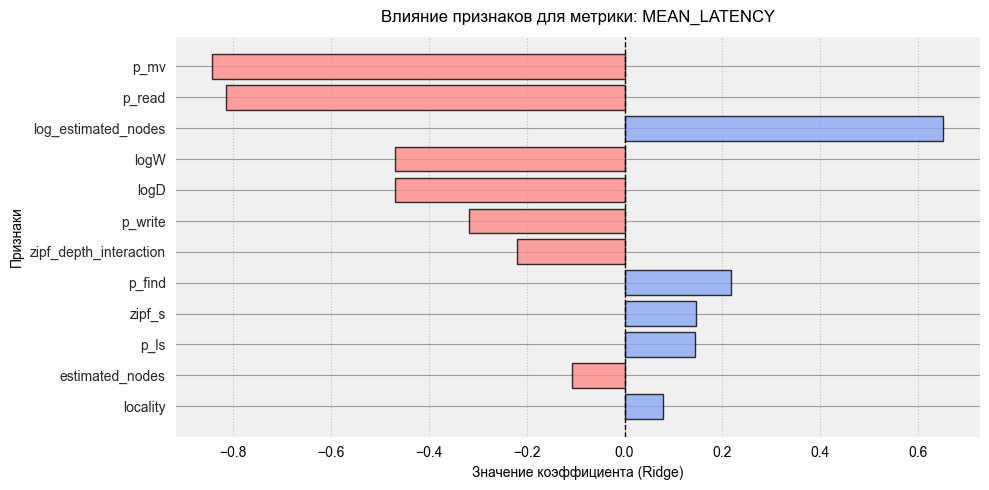

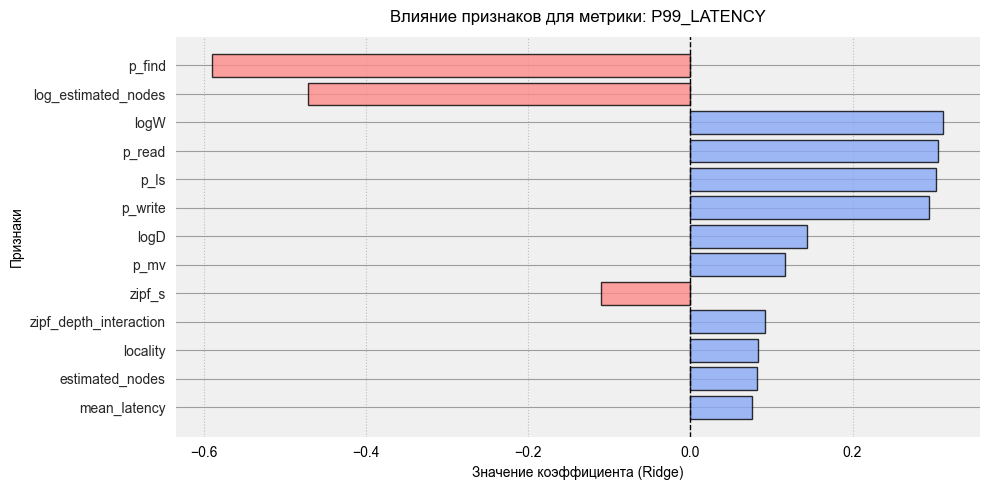

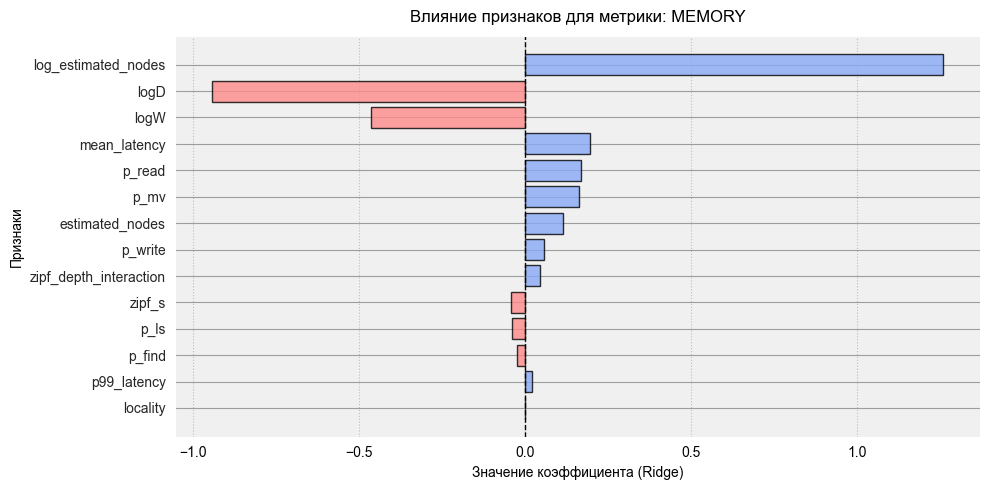

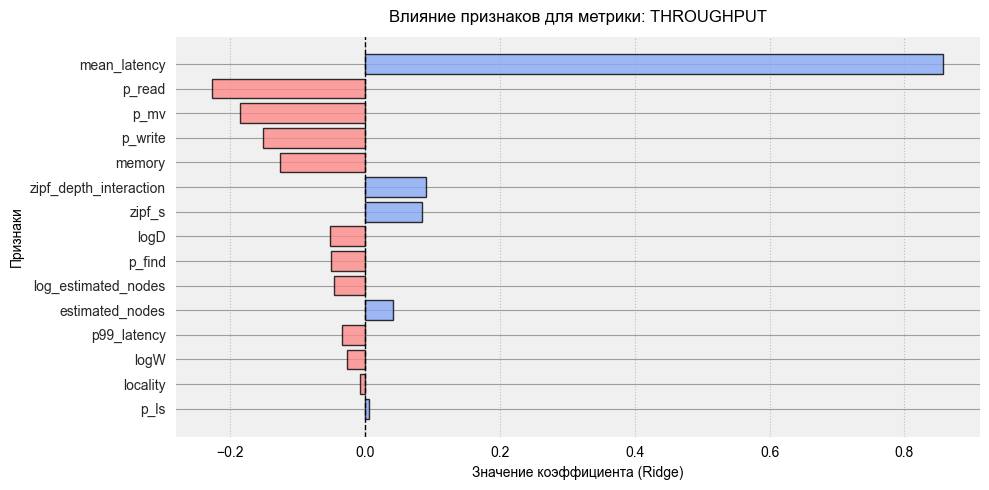

In [224]:

feature_names = list(X_train.columns)
target_names = ['mean_latency', 'p99_latency', 'memory', 'throughput']

for i, estimator in enumerate(best_chain_model.estimators_):
    current_features = feature_names + target_names[:i]
    coefficients = estimator.coef_

    importance_df = pd.DataFrame({
        'Feature': current_features,
        'Coefficient': coefficients,
        'Absolute': np.abs(coefficients)
    }).sort_values(by='Absolute', ascending=True)
    
    plt.figure(figsize=(10, 5))
    colors = ['#89A8F6' if c > 0 else '#FF8A8A' for c in importance_df['Coefficient']]
    
    plt.barh(importance_df['Feature'], importance_df['Coefficient'], color=colors, edgecolor='black', alpha=0.8)
    plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
    
    plt.title(f'Влияние признаков для метрики: {target_names[i].upper()}', fontsize=12, pad=10)
    plt.xlabel('Значение коэффициента (Ridge)')
    plt.ylabel('Признаки')
    plt.grid(axis='x', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()


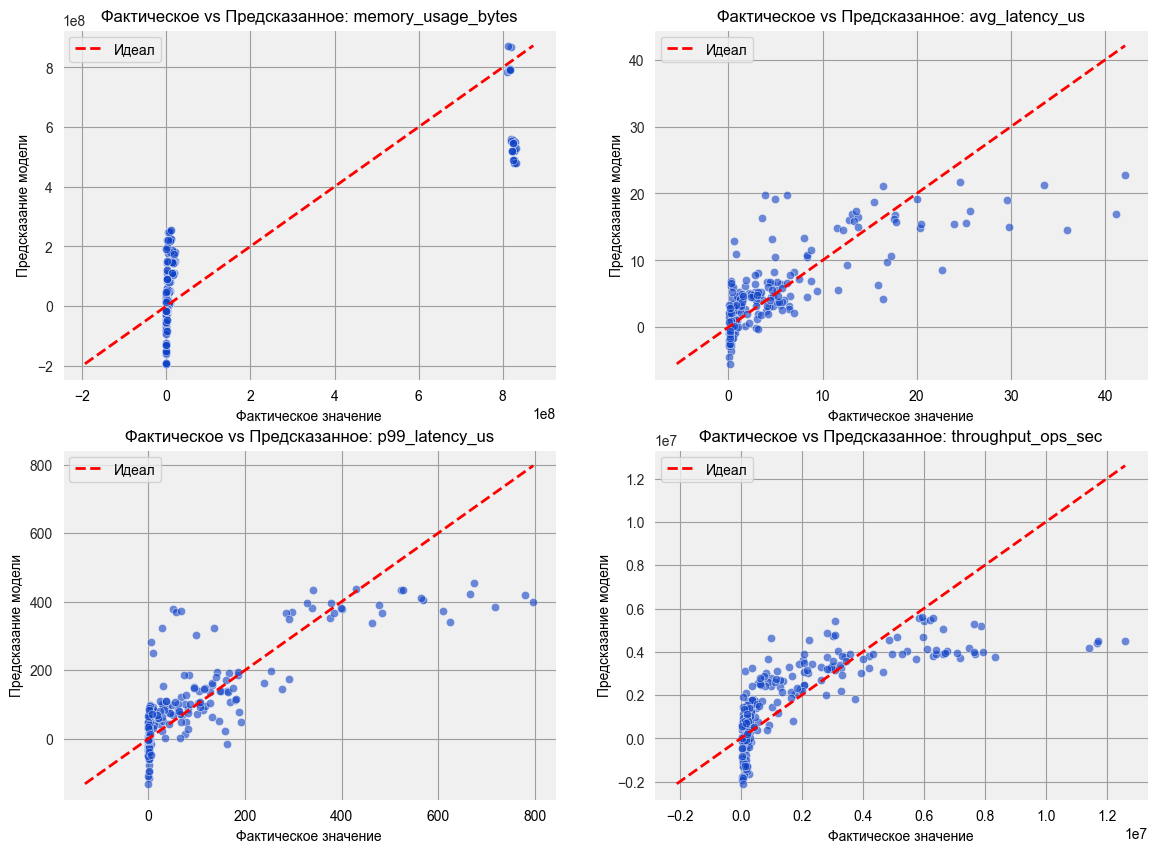

In [225]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, target in enumerate(ordered_targets):
    sns.scatterplot(x=Y_test[target], y=y_preds[target], ax=axes[i], alpha=0.6, color='#0F42C6')

    min_val = min(Y_test[target].min(), y_preds[target].min())
    max_val = max(Y_test[target].max(), y_preds[target].max())
    axes[i].plot([min_val, max_val], [min_val, max_val], '--r', lw=2, label='Идеал')
    
    axes[i].set_title(f"Фактическое vs Предсказанное: {target}")
    axes[i].set_xlabel("Фактическое значение")
    axes[i].set_ylabel("Предсказание модели")
    axes[i].legend()

Text(0.5, 1.0, 'Корреляция ошибок предсказания (Остатки)')

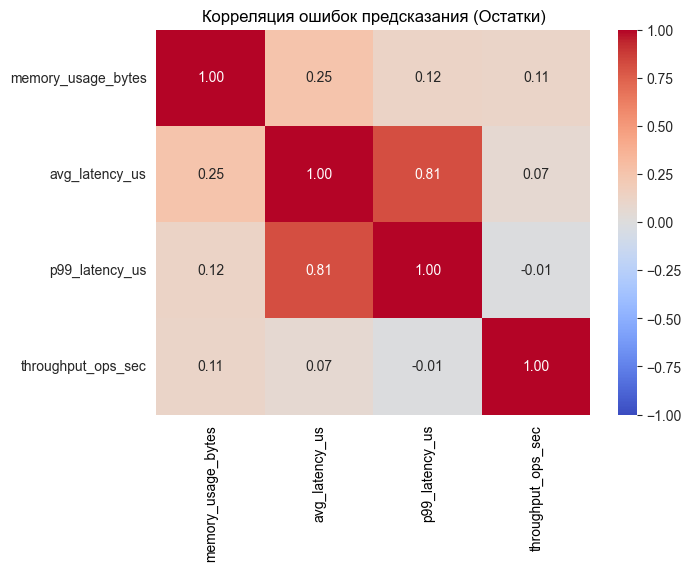

In [226]:
residuals = Y_test - y_preds

plt.figure(figsize=(7, 5))
sns.heatmap(residuals.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Корреляция ошибок предсказания (Остатки)")

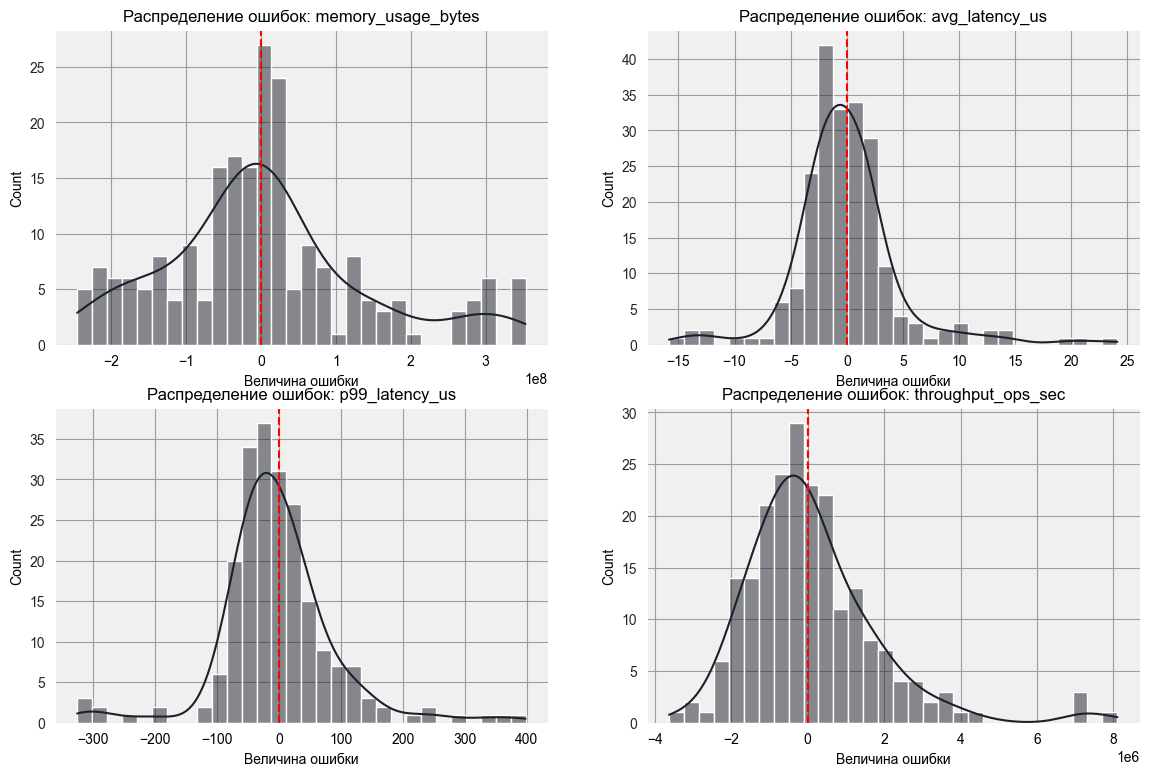

In [227]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for i, target in enumerate(ordered_targets):
    sns.histplot(residuals[target], kde=True, ax=axes[i], color='#1C2029', bins=30)
    axes[i].axvline(x=0, color='r', linestyle='--')
    axes[i].set_title(f"Распределение ошибок: {target}")
    axes[i].set_xlabel("Величина ошибки")
    

# RANDOM FOREST

In [228]:
from sklearn.inspection import PartialDependenceDisplay
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import RegressorChain, MultiOutputRegressor

In [229]:
param_grid = {
    'estimator__n_estimators': [100, 200, 300],
    'estimator__max_depth': [None, 10, 20],
    'estimator__max_features': ['sqrt', 0.33, 'log2'],
    'estimator__min_samples_leaf': [1, 2, 5],
}

multi_rf = MultiOutputRegressor(
    RandomForestRegressor(random_state=42, oob_score=False)
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    multi_rf,
    param_grid,
    n_iter=20,
    cv=kf,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train_scaled, Y_train_scaled)
print("Лучшие параметры:", search.best_params_)
print("Лучший R² (CV):", round(search.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Лучшие параметры: {'estimator__n_estimators': 200, 'estimator__min_samples_leaf': 1, 'estimator__max_features': 'sqrt', 'estimator__max_depth': 10}
Лучший R² (CV): 0.902


In [230]:
best_params = {k.replace('estimator__', ''): v for k, v in search.best_params_.items()}
best_params['random_state'] = 42
best_params['oob_score'] = True

print("Параметры для цепочки:", best_params)

base_rf = RandomForestRegressor(**best_params)
chain_rf = RegressorChain(base_rf, order= [1, 3, 0, 2])
chain_rf.fit(X_train_scaled, Y_train_scaled)

print(f"\nOOB R² первого звена цепочки (memory_usage_bytes): {chain_rf.estimators_[0].oob_score_:.4f}")

Параметры для цепочки: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10, 'random_state': 42, 'oob_score': True}

OOB R² первого звена цепочки (memory_usage_bytes): 0.7755


In [231]:
Y_pred_rf_scaled = chain_rf.predict(X_test_scaled)
Y_pred_rf = scaler_Y.inverse_transform(Y_pred_rf_scaled)

y_preds_rf = pd.DataFrame(Y_pred_rf, columns=ordered_targets, index=Y_test.index)

metrics_rf = []
for target in ordered_targets:
    y_true = Y_test[target]
    y_pr = y_preds_rf[target]
    metrics_rf.append({
        'Target': target,
        'R²': round(r2_score(y_true, y_pr), 4),
        'MAE': round(mean_absolute_error(y_true, y_pr), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pr)), 2),
        'MAPE': f"{mean_absolute_percentage_error(y_true, y_pr)*100:.2f}%",
    })

display(pd.DataFrame(metrics_rf))

,Target,R²,MAE,RMSE,MAPE
0,memory_usage_bytes,0.9996,1618332.86,5450234.22,181.09%
1,avg_latency_us,0.8399,1.27,3.07,32.87%
2,p99_latency_us,0.8386,27.33,66.27,54.18%
3,throughput_ops_sec,0.9100,377639.08,776423.06,25.85%


In [232]:
import joblib

joblib.dump(chain_rf, 'model/B/random_forest_pipeline.joblib')

joblib.dump(scaler_X, 'model/B/scaler_X.joblib')
joblib.dump(scaler_Y, 'model/B/scaler_Y.joblib')

['model/B/scaler_Y.joblib']

Text(0.5, 1.02, 'Random Forest: Фактическое vs Предсказанное')

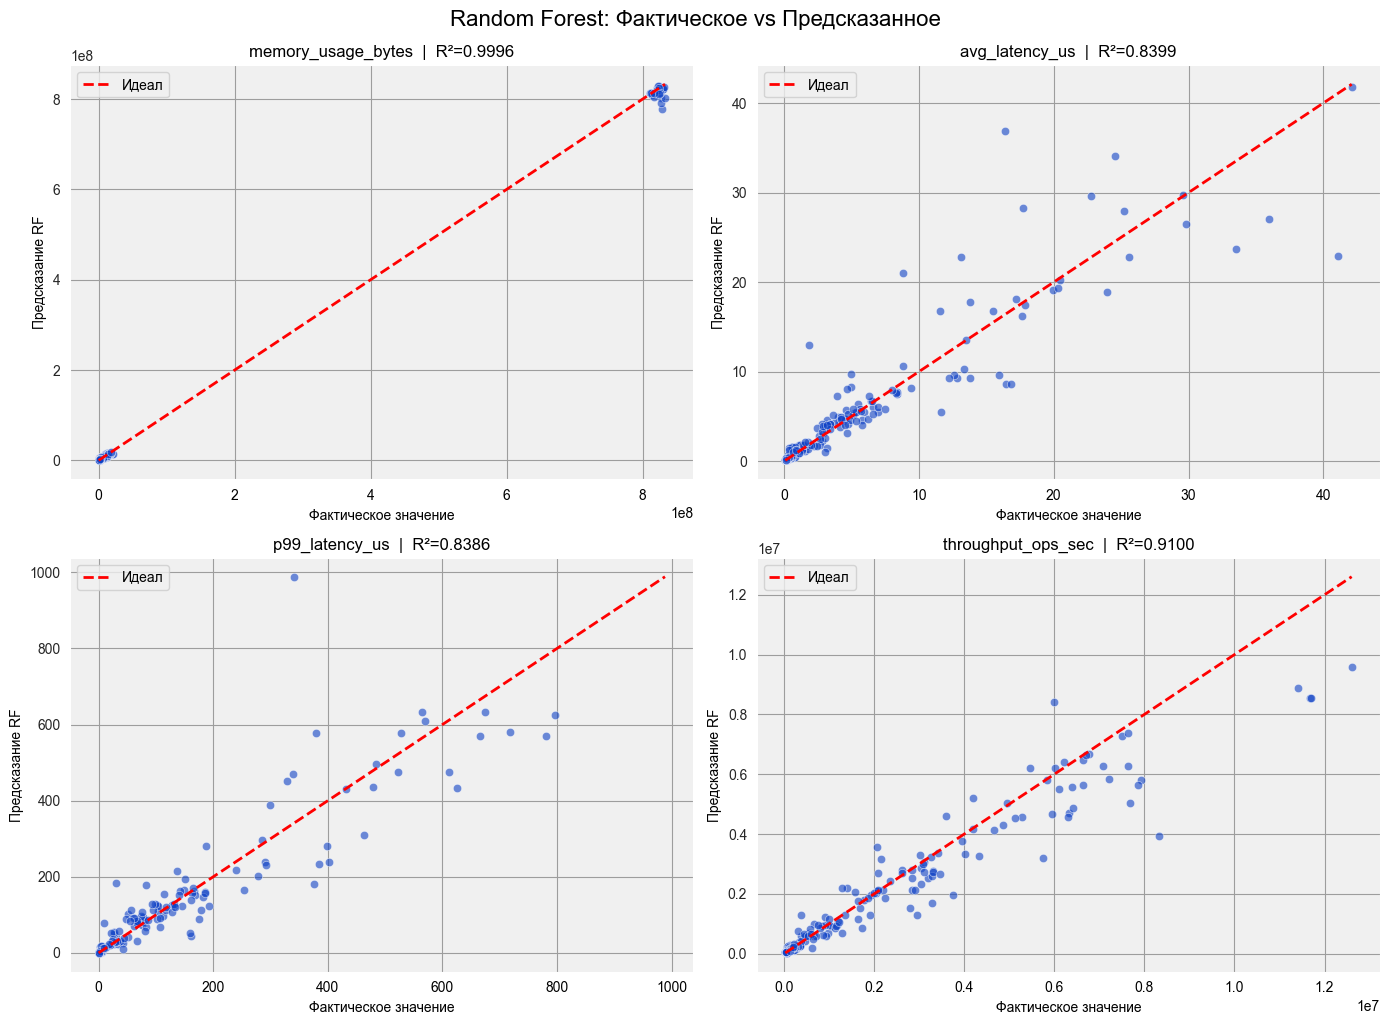

In [233]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, target in enumerate(ordered_targets):
    sns.scatterplot(x=Y_test[target], y=y_preds_rf[target], ax=axes[i], alpha=0.6, color='#0F42C6')

    min_val = min(Y_test[target].min(), y_preds_rf[target].min())
    max_val = max(Y_test[target].max(), y_preds_rf[target].max())
    axes[i].plot([min_val, max_val], [min_val, max_val], '--r', lw=2, label='Идеал')

    r2 = r2_score(Y_test[target], y_preds_rf[target])
    axes[i].set_title(f"{target}  |  R²={r2:.4f}")
    axes[i].set_xlabel("Фактическое значение")
    axes[i].set_ylabel("Предсказание RF")
    axes[i].legend()

plt.tight_layout()
plt.suptitle("Random Forest: Фактическое vs Предсказанное", fontsize=16, y=1.02)

In [234]:
residuals_rf = Y_test.values - Y_pred_rf
resid_df = pd.DataFrame(residuals_rf, columns=ordered_targets, index=Y_test.index)

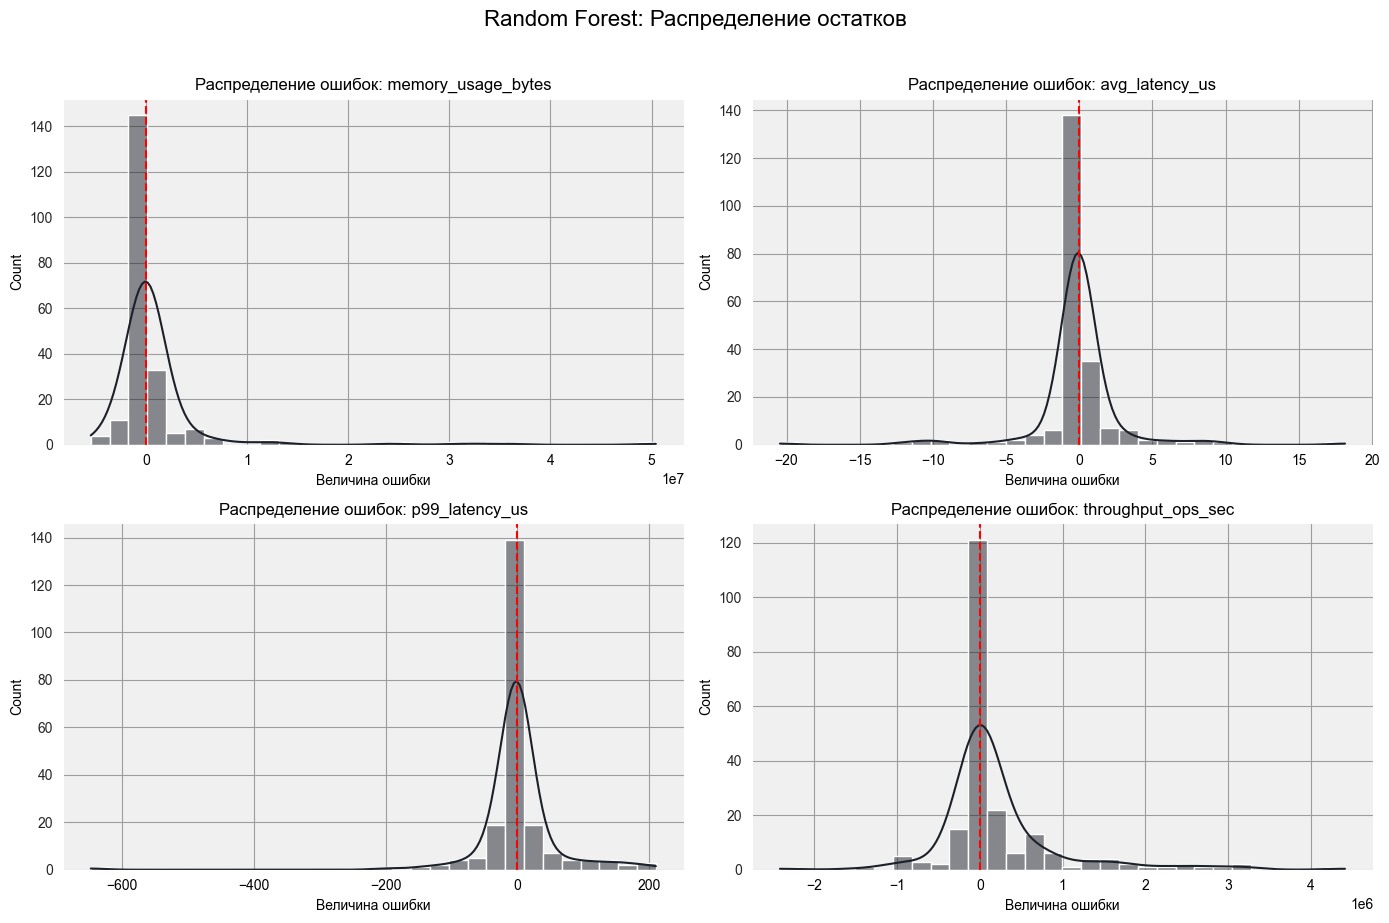

In [235]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for i, target in enumerate(ordered_targets):
    sns.histplot(resid_df[target], kde=True, ax=axes[i], color='#1C2029', bins=30)
    axes[i].axvline(x=0, color='r', linestyle='--')
    axes[i].set_title(f"Распределение ошибок: {target}")
    axes[i].set_xlabel("Величина ошибки")

plt.suptitle("Random Forest: Распределение остатков", fontsize=16, y=1.02)
plt.tight_layout()

Text(0.5, 1.0, 'Корреляция ошибок предсказания RF (остатки)')

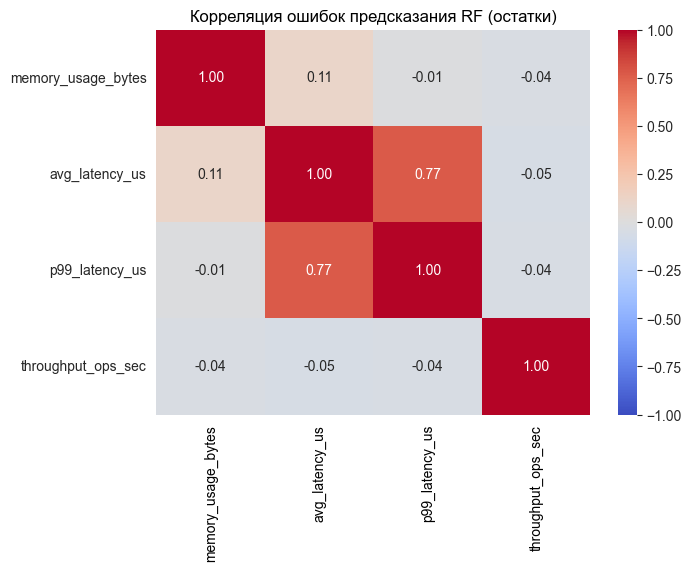

In [236]:
plt.figure(figsize=(7, 5))
sns.heatmap(resid_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Корреляция ошибок предсказания RF (остатки)")

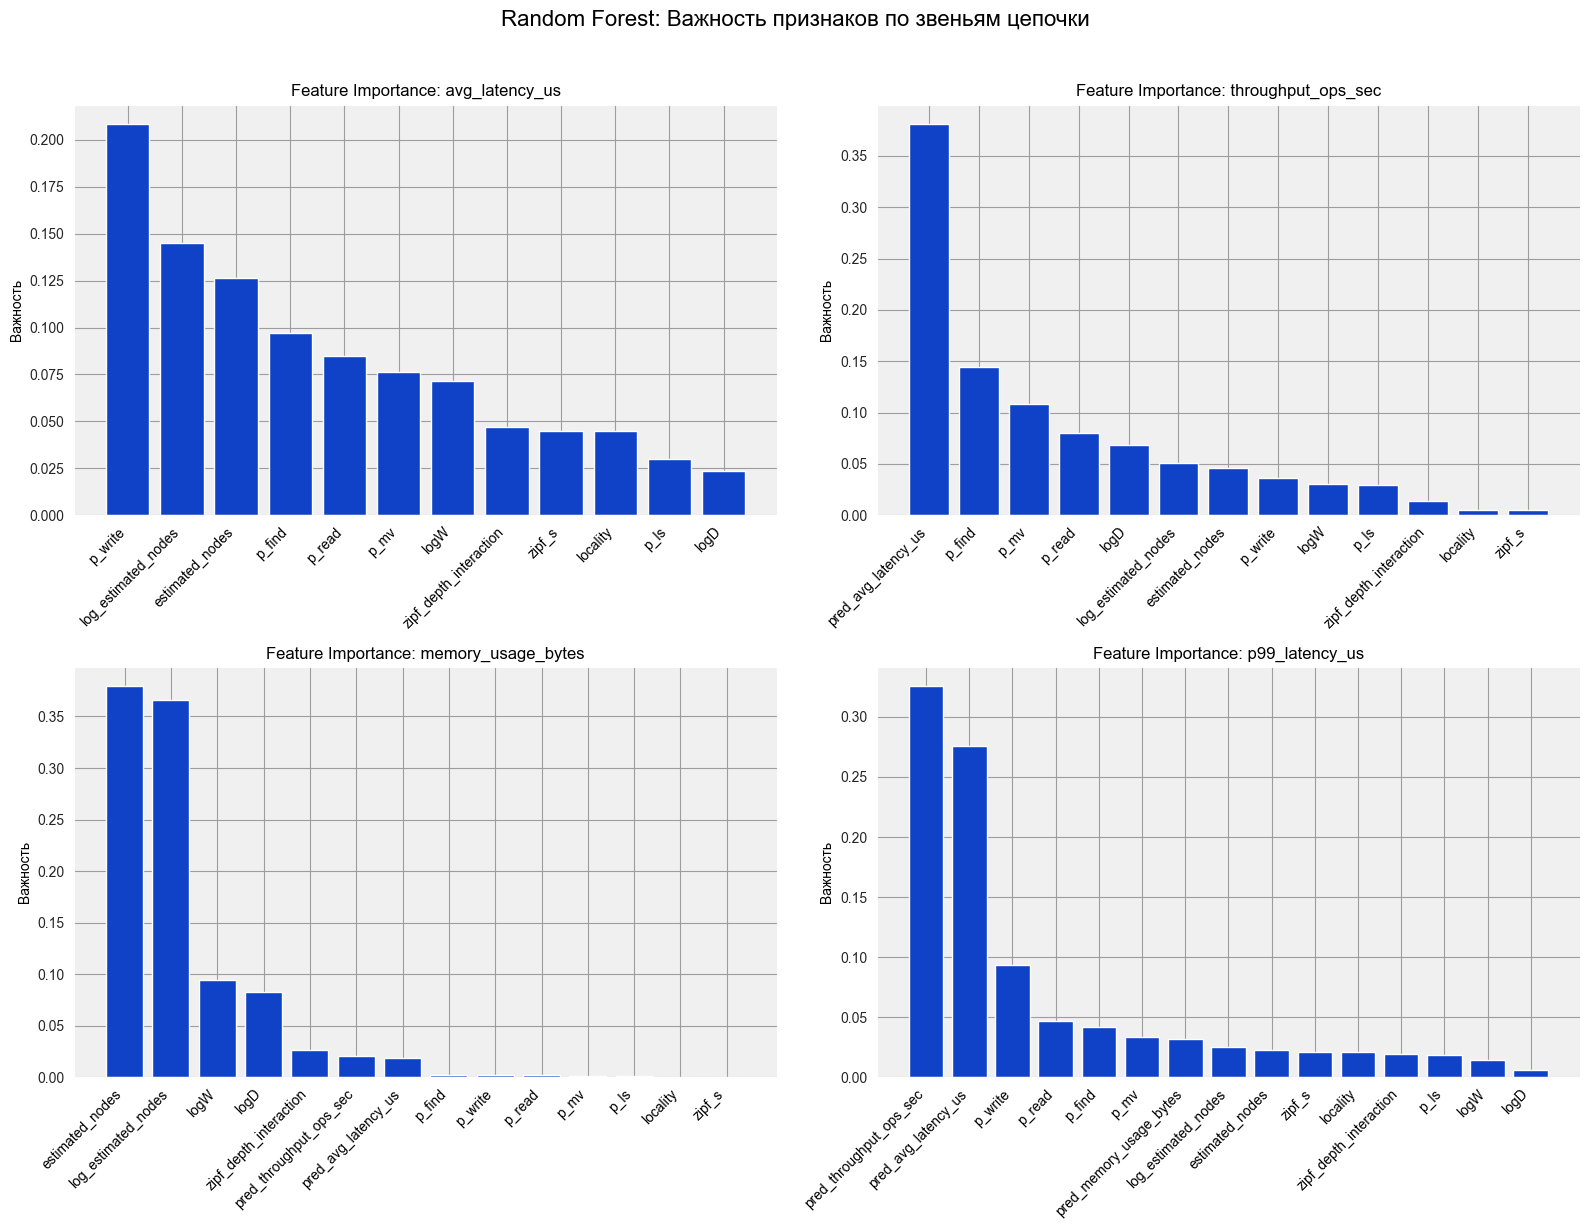

In [237]:
real_feature_names = list(X_train.columns)

order = chain_rf.order_
ordered_target_names = [ordered_targets[idx] for idx in order]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, (estimator, target) in enumerate(zip(chain_rf.estimators_, ordered_target_names)):
    n_original = len(real_feature_names)
    n_extra = estimator.n_features_in_ - n_original

    extra_names = [f"pred_{ordered_target_names[j]}" for j in range(n_extra)]
    all_names = real_feature_names + extra_names

    importances = estimator.feature_importances_
    sorted_idx = np.argsort(importances)[::-1][:15]

    axes[i].bar(range(len(sorted_idx)), importances[sorted_idx], color='#0F42C6')
    axes[i].set_xticks(range(len(sorted_idx)))
    axes[i].set_xticklabels([all_names[j] for j in sorted_idx], rotation=45, ha='right', fontsize=10)
    axes[i].set_title(f"Feature Importance: {target}")
    axes[i].set_ylabel("Важность")

plt.suptitle("Random Forest: Важность признаков по звеньям цепочки", fontsize=16, y=1.02)
plt.tight_layout()